In [36]:
# ============================================================
# 1) Libraries
# ============================================================
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [37]:
# ============================================================
# 2) Configuration
# ============================================================
DATA_PATH = Path("ESS4e04_6-ESS8e02_3-subset.csv")

VOTE_COLS = ["prtvtno", "prtvtbno", "prtvtapt", "prtvtcpt"]

ANALYSIS_VARS = ["gincdif", "dfincac", "gvslvue", "sbbsntx", "sbeqsoc", "sbstrec"]

LIKERT_VARS = ["gincdif", "dfincac", "sbbsntx", "sbeqsoc", "sbstrec"]

VAR_LABELS = {
    "gincdif": "Government should reduce income differences",
    "dfincac": "Large income differences are acceptable",
    "gvslvue": "Unemployed life conditions are a government responsibility",
    "sbbsntx": "Social benefits are too costly for companies",
    "sbeqsoc": "Social benefits lead to equality",
    "sbstrec": "Social benefits are a burden to the economy",
}

VAR_LABELS2 = {
    "gincdif": "A",
    "dfincac": "B",
    "gvslvue": "C",
    "sbbsntx": "D",
    "sbeqsoc": "E",
    "sbstrec": "F",
}

LIKERT_MAP = {
    1: "Agree strongly",
    2: "Agree",
    3: "Neither agree nor disagree",
    4: "Disagree",
    5: "Disagree strongly",
    7: np.nan,
    8: np.nan,
    9: np.nan,
}

LIKERT_ORDER = [
    "Disagree strongly",
    "Disagree",
    "Neither agree nor disagree",
    "Agree",
    "Agree strongly",
]

# Party mappings by column
PARTY_MAPS = {
    "prtvtno": {
        1: "Rødt",
        2: "Sosialistisk Venstreparti",
        3: "Arbeiderpartiet",
        4: "Venstre",
        5: "Kristelig Folkeparti",
        6: "Senterpartiet",
        7: "Høyre",
        8: "Fremskrittspartiet",
        9: "Kystpartiet",
        10: "Other",
        66: np.nan, 77: np.nan, 88: np.nan, 99: np.nan,
    },
    "prtvtbno": {
        1: "Rødt",
        2: "Sosialistisk Venstreparti",
        3: "Arbeiderpartiet",
        4: "Venstre",
        5: "Kristelig Folkeparti",
        6: "Senterpartiet",
        7: "Høyre",
        8: "Fremskrittspartiet",
        9: "Kystpartiet",
        10: "Miljøpartiet De Grønne",
        11: "Other",
        66: np.nan, 77: np.nan, 88: np.nan, 99: np.nan,
    },
    "prtvtapt": {
        1: "Bloco de Esquerda (BE)",
        2: "CDS/PP",
        3: "PCP-PEV (CDU)",
        4: "PCTP-MRPP",
        5: "PDA",
        6: "Partido Humanista",
        7: "PND",
        8: "PNR",
        9: "POUS",
        10: "PSD",
        11: "PS",
        12: "Blank",
        13: "Other",
        66: np.nan, 77: np.nan, 88: np.nan, 99: np.nan,
    },
    "prtvtcpt": {
        1: "PTP-MAS / Agir",
        2: "Bloco de Esquerda (BE)",
        3: "CDU (PCP-PEV)",
        4: "JPP",
        5: "LIVRE/Tempo de Avançar",
        6: "Nós, Cidadãos!",
        7: "PPV/CDC",
        8: "PCTP/MRPP",
        9: "MPT",
        10: "PDR",
        11: "PNR",
        12: "PPM",
        13: "PS",
        14: "PURP",
        15: "PAN",
        16: "PSD/CDS-PP (Portugal à Frente)",
        17: "Blank",
        18: "Other",
        66: np.nan, 77: np.nan, 88: np.nan, 99: np.nan,
    },
}


In [38]:

# ============================================================
# 3) Data preparation
# ============================================================
def load_and_prepare_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    keep_cols = [
        "cntry", "essround",
        "gincdif", "dfincac", "gvslvue", "sbbsntx", "sbeqsoc", "sbstrec",
        *VOTE_COLS
    ]
    df = df[keep_cols].copy()

    # Vote columns numeric (para limpar códigos estranhos)
    for col in VOTE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Recode parties (primeiro vira object, depois replace)
    for col, mapping in PARTY_MAPS.items():
        df[col] = df[col].astype("object").replace(mapping)

    # Unify vote variable
    df["voto_unico"] = df[VOTE_COLS].bfill(axis=1).iloc[:, 0]

    # Filter parties of interest
    df = df[df["voto_unico"].isin(["Arbeiderpartiet", "PS"])].copy()

    # Filter valid ranges
    valid_ranges = {
        "gincdif": 5,
        "dfincac": 5,
        "gvslvue": 10,
        "sbbsntx": 5,
        "sbeqsoc": 5,
        "sbstrec": 5,
    }

    for var, max_val in valid_ranges.items():
        df = df[df[var].between(1, max_val, inclusive="both")].copy()

    return df



In [39]:
# ============================================================
# 4) Statistics
# ============================================================
def cohens_d(x, y):
    """Cohen's d using pooled standard deviation."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return np.nan

    s1, s2 = x.std(ddof=1), y.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan

    return (x.mean() - y.mean()) / pooled_sd


def rank_biserial_from_u(u, n1, n2):
    """Rank-biserial correlation derived from Mann–Whitney U."""
    if n1 == 0 or n2 == 0:
        return np.nan
    return 1 - (2 * u) / (n1 * n2)


def compare_groups(df, group_col, group1, group2, variables):
    """Compare two groups across multiple variables."""
    results = []

    for var in variables:
        x = df.loc[df[group_col] == group1, var].dropna()
        y = df.loc[df[group_col] == group2, var].dropna()

        n1, n2 = len(x), len(y)

        if n1 < 2 or n2 < 2:
            results.append({
                "variable": var,
                "n1": n1, "mean1": np.nan, "sd1": np.nan,
                "n2": n2, "mean2": np.nan, "sd2": np.nan,
                "t": np.nan, "p_t": np.nan,
                "U": np.nan, "p_U": np.nan,
                "cohens_d": np.nan,
                "rank_biserial": np.nan,
            })
            continue

        t_stat, p_t = stats.ttest_ind(x, y, equal_var=False)
        u_stat, p_u = stats.mannwhitneyu(x, y, alternative="two-sided")

        results.append({
            "variable": var,
            "n1": n1,
            "mean1": x.mean(),
            "sd1": x.std(ddof=1),
            "n2": n2,
            "mean2": y.mean(),
            "sd2": y.std(ddof=1),
            "t": t_stat,
            "p_t": p_t,
            "U": u_stat,
            "p_U": p_u,
            "cohens_d": cohens_d(x, y),
            "rank_biserial": rank_biserial_from_u(u_stat, n1, n2),
        })

    return pd.DataFrame(results)



In [40]:
# ============================================================
# 5) Plot helpers
# ============================================================
def plot_violin_grid(df08, df16, variables, labels):
    sns.set_theme(style="whitegrid")

    # Definir escala por variável
    scale_map = {
        "gvslvue": (0, 10),  # essa é 0–10
        "default": (1, 5)    # as outras são 1–5
    }

    fig, axs = plt.subplots(nrows=len(variables), ncols=2, figsize=(13, 24))

    for i, var in enumerate(variables):

        # definir limites e ticks
        ymin, ymax = scale_map.get(var, scale_map["default"])
        ylimit_top = ymax + 1

        if ymax == 5:
            yticks = [1, 2, 3, 4, 5]
        else:
            yticks = list(range(ymin, ymax + 1))

        for j, (df_year, year) in enumerate([(df08, 2008), (df16, 2016)]):

            ax = axs[i, j]

            # violino
            sns.violinplot(
                data=df_year[df_year[var].notna()],
                x="cntry",
                y=var,
                ax=ax,
                inner="quartile",
                cut=0,
                palette="coolwarm"
            )

            # médias por país
            means = df_year.groupby("cntry")[var].mean()

            for k, country in enumerate(means.index):
                ax.scatter(k, means[country], color="red", s=35, zorder=10)

            # título e labels
            ax.set_title(f"{labels[var]} — {year}")

            # limites e ticks do eixo y
            ax.set_ylim(0, ylimit_top)
            ax.set_yticks(yticks)

            # ylabel só na coluna esquerda
            ax.set_ylabel(labels[var] if j == 0 else "")

    plt.tight_layout()
    plt.show()

In [41]:
# ============================================================
# 6) Run the analysis
# ============================================================
dados = load_and_prepare_data(DATA_PATH)

df08 = dados[dados["essround"] == 4].copy()
df16 = dados[dados["essround"] == 8].copy()

res_2008 = compare_groups(df08, "cntry", "NO", "PT", ANALYSIS_VARS)
res_2016 = compare_groups(df16, "cntry", "NO", "PT", ANALYSIS_VARS)

# Optional: rounded results for display
res_2008_display = res_2008.round(3)
res_2016_display = res_2016.round(3)

print("2008")
display(res_2008_display)

print("2016")
display(res_2016_display)


2008


/tmp/ipykernel_3779/2633559917.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["voto_unico"] = df[VOTE_COLS].bfill(axis=1).iloc[:, 0]


,variable,n1,mean1,sd1,n2,mean2,sd2,t,p_t,U,p_U,cohens_d,rank_biserial
0,gincdif,393,2.178,0.817,464,1.800,0.747,7.029,0.00,115500.5,0.000,0.485,-0.267
1,dfincac,393,2.845,0.917,464,2.728,1.029,1.750,0.08,98573.5,0.031,0.119,-0.081
2,gvslvue,393,7.756,1.688,464,7.157,2.139,4.575,0.00,105846.5,0.000,0.308,-0.161
3,sbbsntx,393,3.130,0.884,464,2.748,0.931,6.149,0.00,112587.0,0.000,0.420,-0.235
4,sbeqsoc,393,2.300,0.736,464,2.498,0.911,-3.511,0.00,80856.5,0.001,-0.237,0.113
5,sbstrec,393,3.295,0.925,464,2.763,1.022,7.995,0.00,117870.5,0.000,0.544,-0.293


2016


,variable,n1,mean1,sd1,n2,mean2,sd2,t,p_t,U,p_U,cohens_d,rank_biserial
0,gincdif,394,2.086,0.849,259,1.734,0.728,5.668,0.000,62935.5,0.000,0.439,-0.233
1,dfincac,394,3.211,1.008,259,3.282,1.093,-0.839,0.402,48831.0,0.330,-0.068,0.043
2,gvslvue,394,7.566,1.539,259,7.232,2.044,2.247,0.025,55972.0,0.033,0.190,-0.097
3,sbbsntx,394,3.492,0.903,259,3.027,1.009,6.006,0.000,63996.5,0.000,0.492,-0.254
4,sbeqsoc,394,2.226,0.736,259,2.602,0.965,-5.341,0.000,40859.5,0.000,-0.451,0.199
5,sbstrec,394,3.251,0.965,259,2.672,1.014,7.282,0.000,67210.5,0.000,0.588,-0.317


In [42]:
# ============================================================
# 7) Likert tables
# ============================================================
df08 = add_likert_categories(df08, LIKERT_VARS)
df16 = add_likert_categories(df16, LIKERT_VARS)

tabela_2008 = (
    pd.crosstab(df08["cntry"], df08["gincdif_cat"], normalize="index") * 100
).reindex(columns=LIKERT_ORDER)

tabela_2016 = (
    pd.crosstab(df16["cntry"], df16["gincdif_cat"], normalize="index") * 100
).reindex(columns=LIKERT_ORDER)

display(tabela_2008.round(1))
display(tabela_2016.round(1))


gincdif_cat,Disagree strongly,Disagree,Neither agree nor disagree,Agree,Agree strongly
cntry,,,,,
NO,0.8,5.9,21.6,53.9,17.8
PT,0.6,3.4,5.6,55.8,34.5


gincdif_cat,Disagree strongly,Disagree,Neither agree nor disagree,Agree,Agree strongly
cntry,,,,,
NO,0.5,6.9,17.0,52.0,23.6
PT,0.0,3.5,6.2,50.6,39.8


/tmp/ipykernel_3779/3391416805.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3779/3391416805.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3779/3391416805.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3779/3391416805.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3779/3391416805.py:31: Future

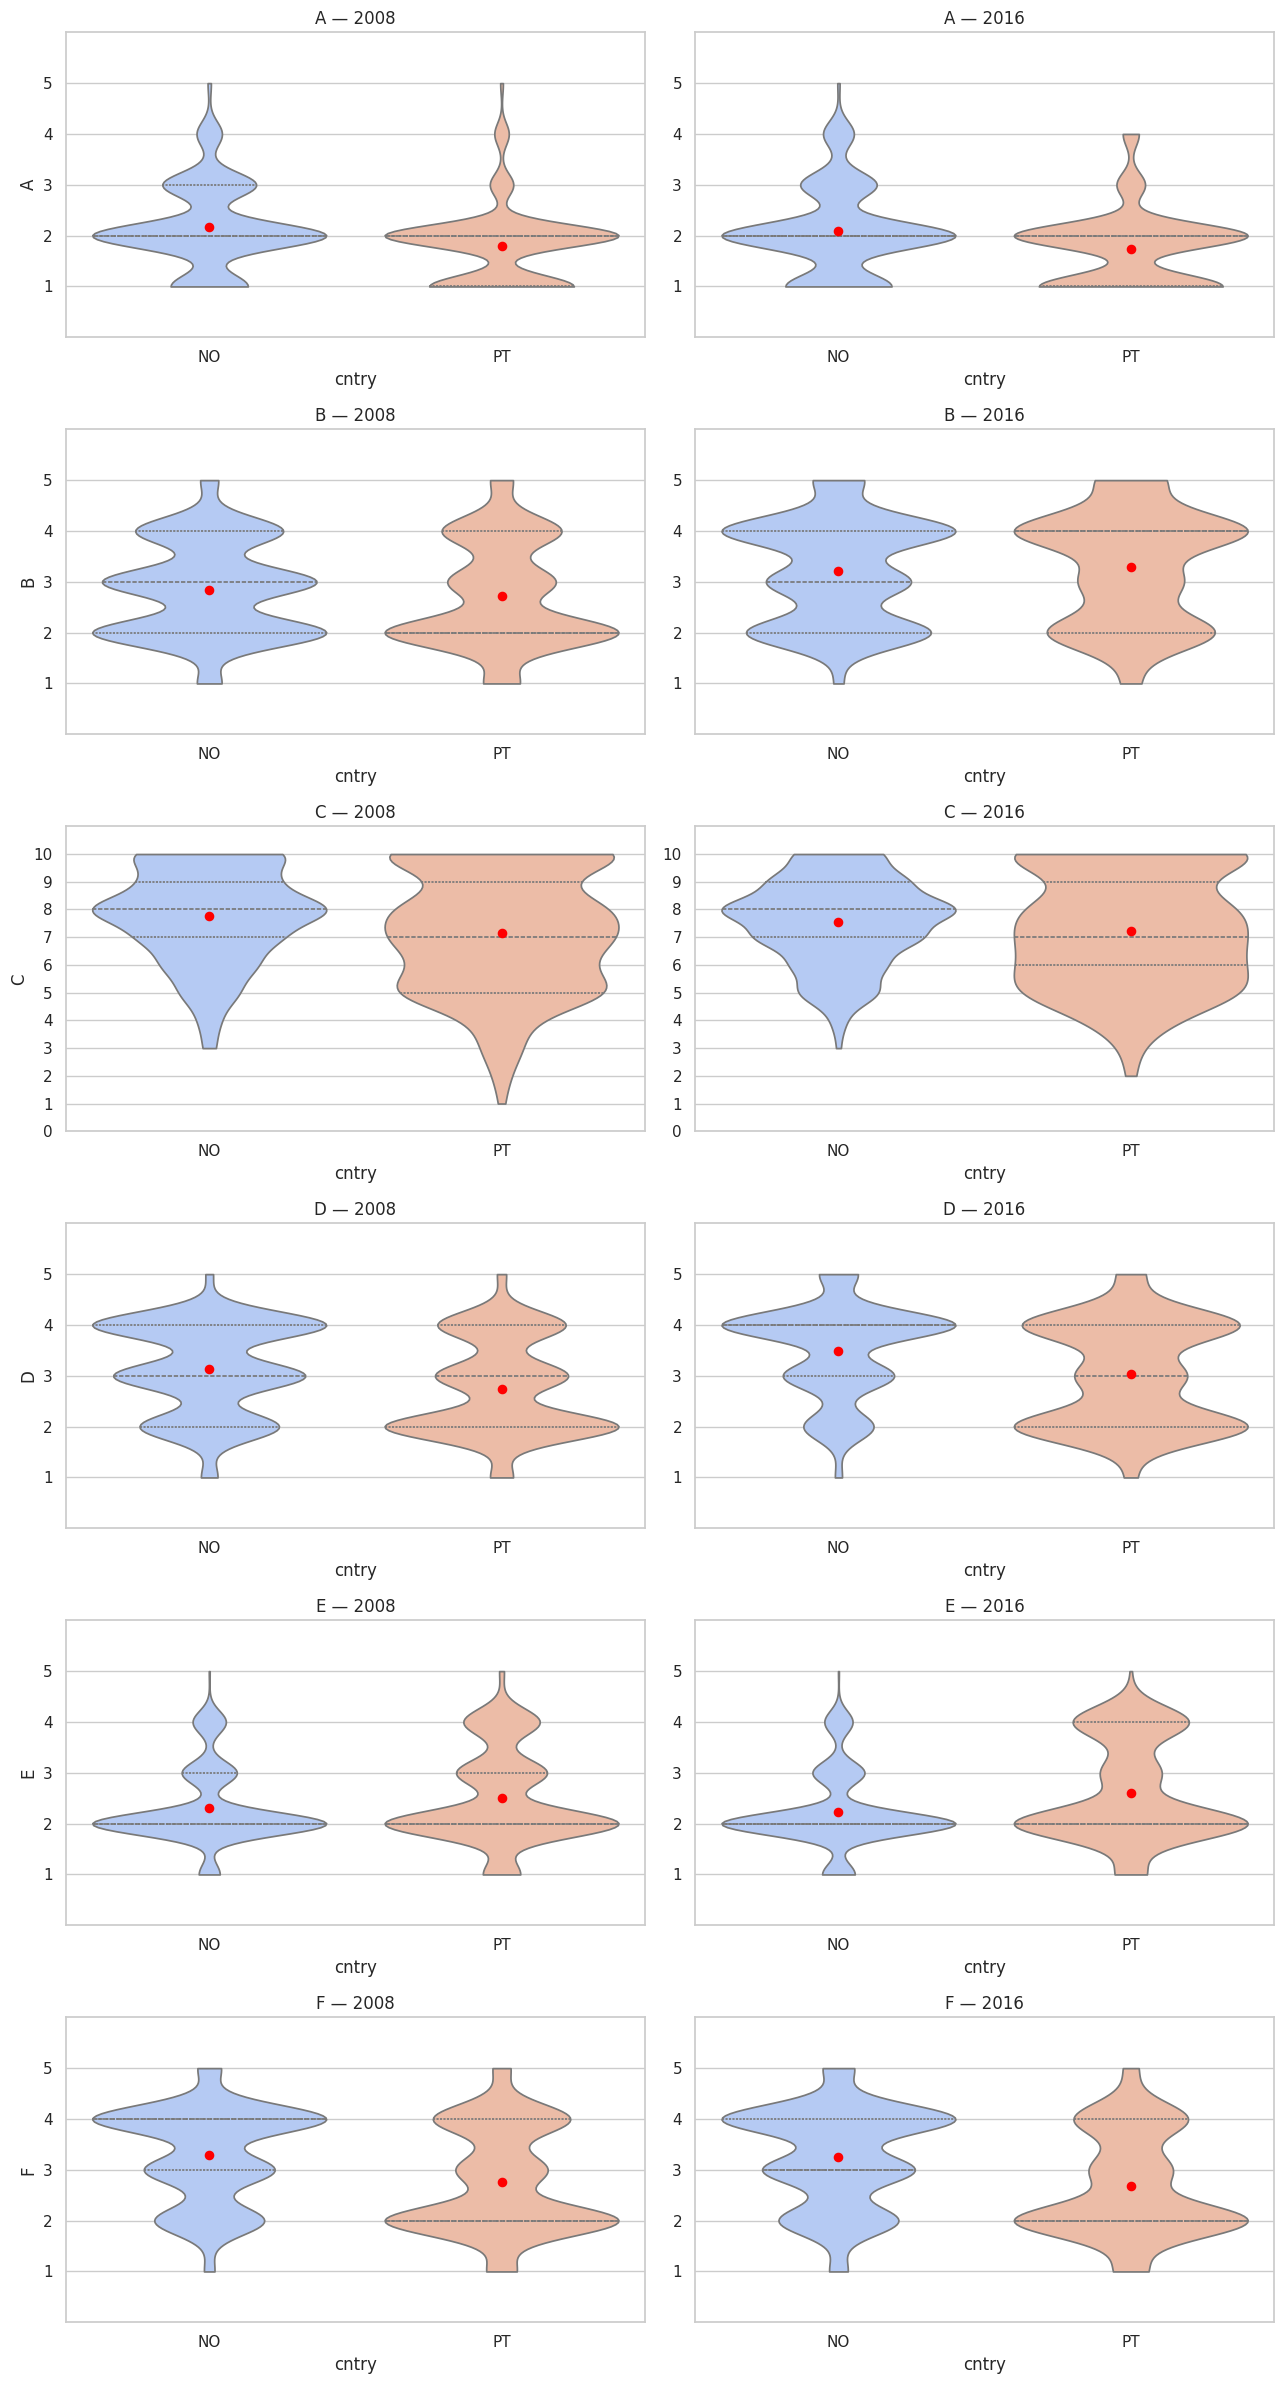

In [43]:
# ============================================================
# 8) Visualisation
# ============================================================
plot_violin_grid(df08, df16, ANALYSIS_VARS, VAR_LABELS2)